In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    ID_COL,
    TARGET_COL,
    RANDOM_STATE,
    PROCESSED_DATA_DIR,
    SUBMISSION_DIR,
    REPORT_DIR,
    FIG_DIR,
)
from src.data_loader import load_application_data
from src.preprocessing import prepare_main_table_with_bureau_and_previous
from src.train import train_catboost_cv

In [2]:
train, test, sample_sub, data_dir = load_application_data()

bureau_features = pd.read_parquet(PROCESSED_DATA_DIR / "bureau_features.parquet")
previous_features = pd.read_parquet(PROCESSED_DATA_DIR / "previous_application_features.parquet")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Bureau features shape:", bureau_features.shape)
print("Previous features shape:", previous_features.shape)

Train shape: (307511, 122)
Test shape: (48744, 121)
Bureau features shape: (356255, 37)
Previous features shape: (356255, 39)


In [3]:
print("bureau_features unique key:", bureau_features[ID_COL].is_unique)
print("previous_features unique key:", previous_features[ID_COL].is_unique)

print("bureau_features rows:", len(bureau_features))
print("previous_features rows:", len(previous_features))

bureau_cols = [c for c in bureau_features.columns if c != ID_COL]
prev_cols = [c for c in previous_features.columns if c != ID_COL]

print("Number of bureau-derived columns:", len(bureau_cols))
print("Number of previous-derived columns:", len(prev_cols))

bureau_features unique key: True
previous_features unique key: True
bureau_features rows: 356255
previous_features rows: 356255
Number of bureau-derived columns: 36
Number of previous-derived columns: 38


In [4]:
X, y, X_test, test_ids, categorical_cols, numeric_cols = prepare_main_table_with_bureau_and_previous(
    train=train,
    test=test,
    bureau_features=bureau_features,
    previous_features=previous_features,
)

print("Merged train features:", X.shape)
print("Merged test features :", X_test.shape)
print("Categorical columns  :", len(categorical_cols))
print("Numeric columns      :", len(numeric_cols))

bureau_feature_names = [c for c in X.columns if c.startswith("BUREAU_")]
prev_feature_names = [c for c in X.columns if c.startswith("PREV_")]

print("BUREAU feature count:", len(bureau_feature_names))
print("PREV feature count  :", len(prev_feature_names))

Merged train features: (307511, 195)
Merged test features : (48744, 195)
Categorical columns  : 16
Numeric columns      : 179
BUREAU feature count: 36
PREV feature count  : 38


In [5]:
results = train_catboost_cv(
    X=X,
    y=y,
    X_test=X_test,
    categorical_cols=categorical_cols,
    random_state=RANDOM_STATE,
)

baseline_mean_auc = 0.759922
baseline_oof_auc = 0.759895

bureau_mean_auc = 0.765376
bureau_oof_auc = 0.765354

print("Fold AUC scores:", [round(score, 6) for score in results["fold_scores"]])
print("Mean fold AUC :", round(np.mean(results["fold_scores"]), 6))
print("OOF AUC       :", round(results["overall_auc"], 6))
print("Lift vs bureau-only OOF:", round(results["overall_auc"] - bureau_oof_auc, 6))

Fold 1 AUC: 0.769614
Fold 2 AUC: 0.778521
Fold 3 AUC: 0.770390
Fold 4 AUC: 0.777536
Fold 5 AUC: 0.768885
Fold AUC scores: [0.769614, 0.778521, 0.77039, 0.777536, 0.768885]
Mean fold AUC : 0.772989
OOF AUC       : 0.772974
Lift vs bureau-only OOF: 0.00762


In [6]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: results["test_preds"],
})

submission_path = SUBMISSION_DIR / "model_v3_bureau_previous.csv"
submission.to_csv(submission_path, index=False)

comparison_df = pd.DataFrame({
    "model": [
        "baseline_main_table",
        "main_table_plus_bureau",
        "main_table_plus_bureau_plus_previous",
    ],
    "mean_fold_auc": [
        baseline_mean_auc,
        bureau_mean_auc,
        np.mean(results["fold_scores"]),
    ],
    "oof_auc": [
        baseline_oof_auc,
        bureau_oof_auc,
        results["overall_auc"],
    ],
})

comparison_df["oof_lift_vs_baseline"] = comparison_df["oof_auc"] - baseline_oof_auc
comparison_df["oof_lift_vs_bureau"] = comparison_df["oof_auc"] - bureau_oof_auc

print("Submission saved to:", submission_path)
display(comparison_df)
display(submission.head())

Submission saved to: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v3_bureau_previous.csv


,model,mean_fold_auc,oof_auc,oof_lift_vs_baseline,oof_lift_vs_bureau
0,baseline_main_table,0.759922,0.759895,0.000000,-0.005459
1,main_table_plus_bureau,0.765376,0.765354,0.005459,0.000000
2,main_table_plus_bureau_plus_previous,0.772989,0.772974,0.013079,0.007620


,SK_ID_CURR,TARGET
0,100001,0.312351
1,100005,0.634159
2,100013,0.217608
3,100028,0.260761
4,100038,0.703929


In [7]:
feature_importance = results["feature_importance"].copy()

feature_importance["source"] = np.where(
    feature_importance["feature"].str.startswith("BUREAU_"),
    "bureau",
    np.where(
        feature_importance["feature"].str.startswith("PREV_"),
        "previous_application",
        "main_table",
    ),
)

display(feature_importance.head(30))

top_prev_features = feature_importance[
    feature_importance["feature"].str.startswith("PREV_")
].head(15)

print("Top previous_application features:")
display(top_prev_features)

,feature,importance,source
75,EXT_SOURCE_3,12.081369,main_table
74,EXT_SOURCE_2,9.990784,main_table
73,EXT_SOURCE_1,5.582909,main_table
58,DAYS_BIRTH,3.493897,main_table
1,AMT_CREDIT,3.484538,main_table
2,AMT_GOODS_PRICE,3.000577,main_table
0,AMT_ANNUITY,2.796443,main_table
46,BUREAU_DEBT_CREDIT_RATIO_MEAN,2.615115,bureau
59,DAYS_EMPLOYED,2.613010,main_table
54,CODE_GENDER,1.762811,main_table


Top previous_application features:


,feature,importance,source
167,PREV_PREV_CREDIT_GOODS_RATIO_MEAN,1.445628,previous_application
153,PREV_CNT_PAYMENT_MAX,1.431482,previous_application
160,PREV_PREV_APPROVED_AMT_CREDIT_MAX,1.059066,previous_application
177,PREV_REFUSAL_RATE,1.038883,previous_application
142,PREV_AMT_ANNUITY_MEAN,1.012400,previous_application
156,PREV_DAYS_DECISION_MEAN,0.866923,previous_application
171,PREV_PREV_IS_APPROVED_SUM,0.782882,previous_application
157,PREV_PREV_ANNUITY_CREDIT_RATIO_MEAN,0.763934,previous_application
169,PREV_PREV_DAYS_DECISION_ABS_MIN,0.757244,previous_application
154,PREV_CNT_PAYMENT_MEAN,0.708603,previous_application


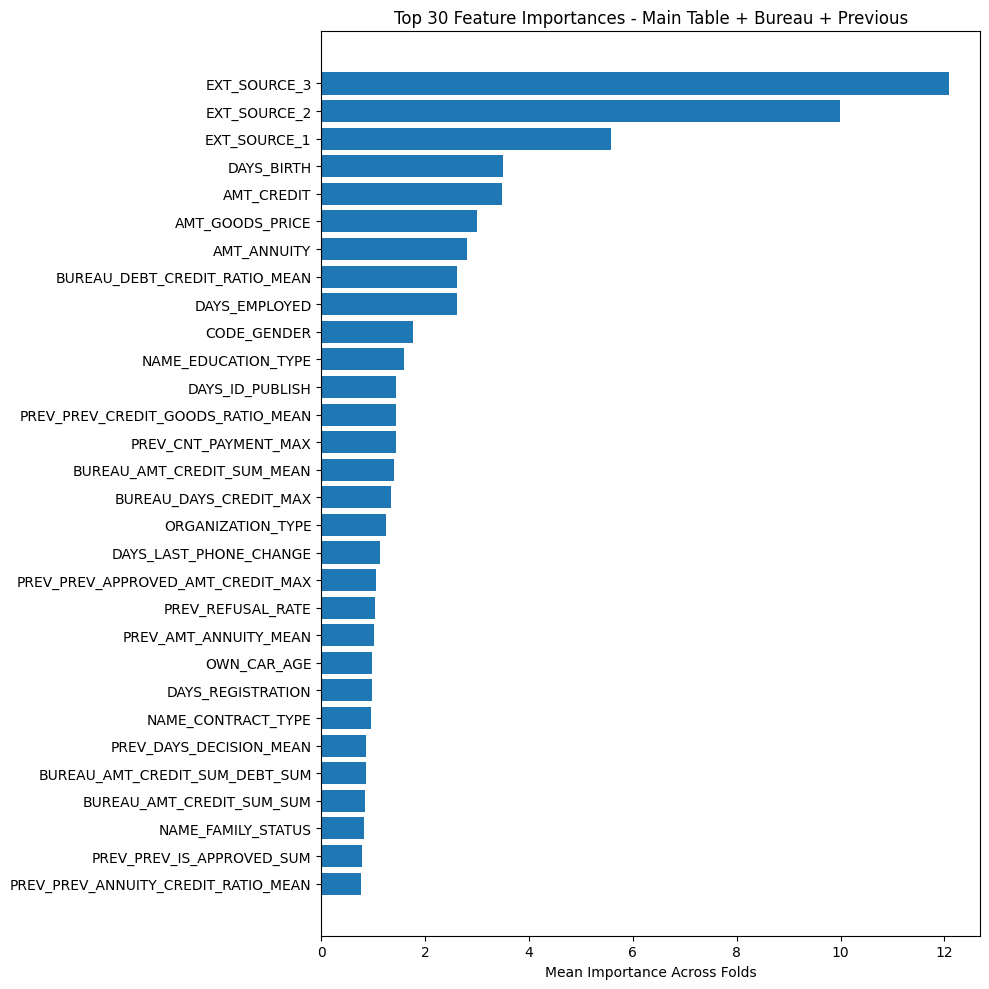

Figure saved to: C:\Coding\Home-Credit-Default-Risk\outputs\figures\model_v3_bureau_previous_feature_importance.png


In [8]:
plot_df = feature_importance.head(30).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 30 Feature Importances - Main Table + Bureau + Previous")
plt.xlabel("Mean Importance Across Folds")
plt.tight_layout()

fig_path = FIG_DIR / "model_v3_bureau_previous_feature_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", fig_path)

In [9]:
report_lines = [
    "# Model V3 Results - Main Table + Bureau + Previous Application",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Bureau feature table shape: {bureau_features.shape}",
    f"- Previous application feature table shape: {previous_features.shape}",
    f"- Final merged train feature matrix: {X.shape}",
    f"- Final merged test feature matrix: {X_test.shape}",
    f"- Number of categorical columns: {len(categorical_cols)}",
    f"- Number of numeric columns: {len(numeric_cols)}",
    f"- Number of bureau-derived columns used in model: {len(bureau_feature_names)}",
    f"- Number of previous-derived columns used in model: {len(prev_feature_names)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {results['n_splits']}",
    f"- Fold AUC scores: {[round(score, 6) for score in results['fold_scores']]}",
    f"- Mean fold AUC: {np.mean(results['fold_scores']):.6f}",
    f"- OOF AUC: {results['overall_auc']:.6f}",
    "",
    "## Comparison",
    f"- Baseline mean fold AUC: {baseline_mean_auc:.6f}",
    f"- Baseline OOF AUC: {baseline_oof_auc:.6f}",
    f"- Bureau model mean fold AUC: {bureau_mean_auc:.6f}",
    f"- Bureau model OOF AUC: {bureau_oof_auc:.6f}",
    f"- OOF lift vs baseline: {results['overall_auc'] - baseline_oof_auc:.6f}",
    f"- OOF lift vs bureau-only model: {results['overall_auc'] - bureau_oof_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- Feature importance figure: {fig_path}",
    "",
    "## Notes",
    "- This model adds previous_application aggregated features on top of the main table and bureau features.",
    "- The goal is to measure whether previous Home Credit application history improves discrimination beyond bureau-only history.",
]

report_text = "\n".join(report_lines)

report_path = REPORT_DIR / "model_v3_bureau_previous.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Report saved to:", report_path)

Report saved to: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v3_bureau_previous.md
